In [15]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
import csv  
from matplotlib.colors import ListedColormap
from matplotlib.colors import TwoSlopeNorm
from cartopy.feature import LAKES

<h1> Load data

In [2]:
# EPA Idling data
oni_file = pd.read_csv('ONI_2022v1_projected_from_full_annual_20240226_monthly_18jun2024_nf_v5.csv',skiprows=14)
hotelling_file = pd.read_csv('HOTELING_2022v1_monthly_20240305_18jun2024_nf_v5.csv',skiprows=19)

cols = [
    "country_cd", "region_cd", "tribal_code", "census_tract_cd", "shape_id", "scc",
    "act_parm_type_cd", "act_parm_uofmsr", "activity_type", "ann_parm_value",
    "calc_year", "date_updated", "data_set_id",
    "jan_value", "feb_value", "mar_value", "apr_value", "may_value", "jun_value",
    "jul_value", "aug_value", "sep_value", "oct_value", "nov_value", "dec_value",
    "comment"
]

# Headers for epa files
oni_file.columns = cols
hotelling_file.columns = cols

In [3]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

In [4]:
# Upload LOCUS county level idling data for Illinois
county_out = gpd.read_file('LOCUS_CountyIdling.shp')
county_out = county_out.to_crs('EPSG:4326')

base_cmap = gpd.clip(county_out, cmap_cty.to_crs('EPSG:4326'))  #clip to CMAP region

<h1> Visualize LOCUS Data at the County-Level

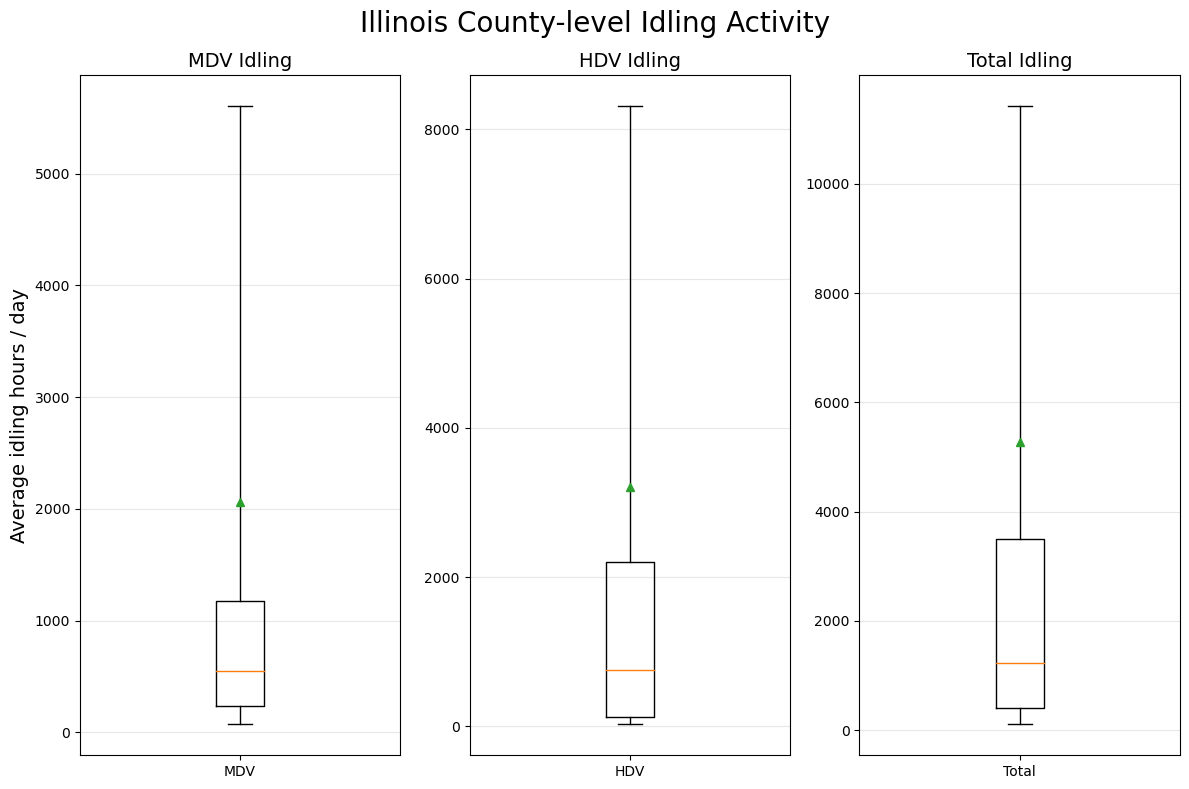

In [5]:
# set dicts
cols = ["MDT_avg_da", "HDT_avg_da", "Total_avg_"]
dfp = county_out[cols].replace([np.inf, -np.inf], np.nan).dropna(how="any")
dfp = dfp.rename(columns={
    "MDT_avg_da": "MDV",
    "HDT_avg_da": "HDV",
    "Total_avg_": "Total"
})

data_order = ["MDV", "HDV", "Total"]
data_arrays = {k: dfp[k].values for k in data_order}


# plot box & whisker
fig, axes = plt.subplots(1, 3, figsize=(12, 8)) 

for i, (ax, name) in enumerate(zip(axes, data_order)):
    ax.boxplot(
        [data_arrays[name]],
        labels=[name],
        whis=(5, 95), #whiskers are 5th and 95th percentiles
        showmeans=True,  # mean is a green triangle 
        showfliers=False,  # No outliers (they really skew the plots)
        notch=False 
    )
    ax.set_title(f"{name} Idling",fontsize=14)
    if i == 0:
        ax.set_ylabel("Average idling hours / day", fontsize=14)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=True) 
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Illinois County-level Idling Activity",fontsize=20)
fig.tight_layout()
plt.show()

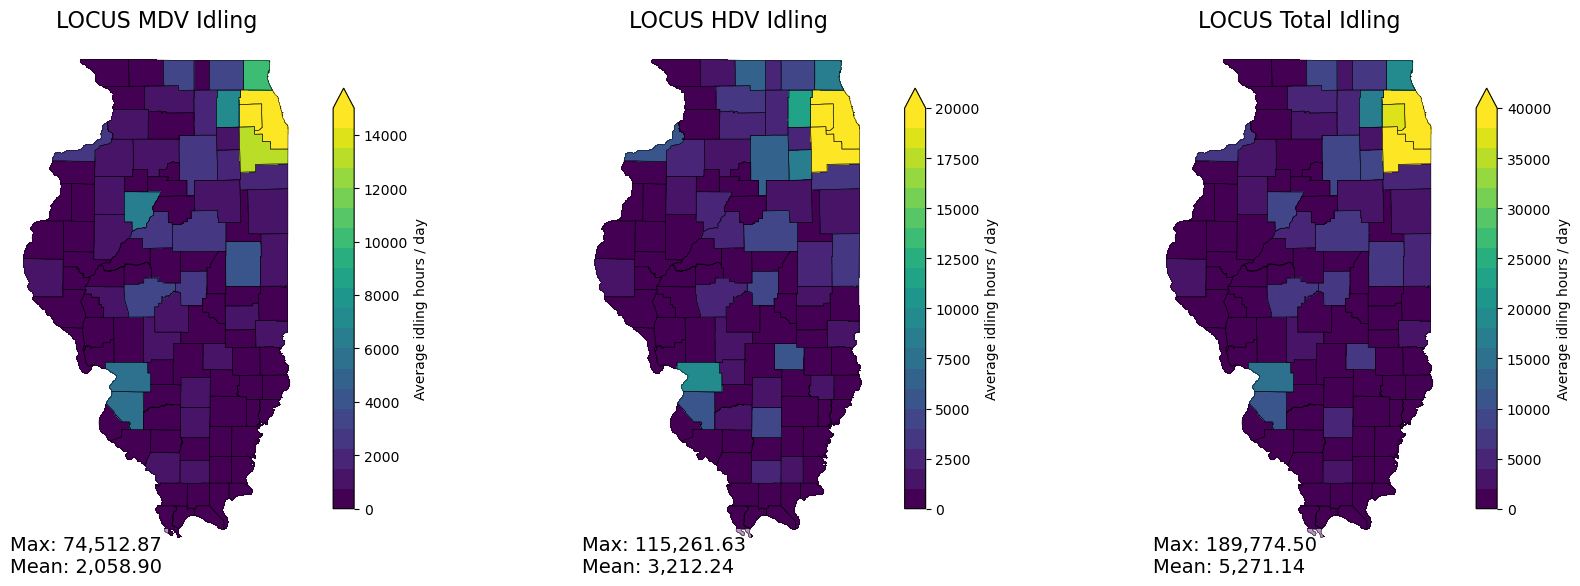

In [6]:
# discrete colorbar  -- can change colormap here as well if neccessary 
bwr_colors = plt.cm.viridis(np.linspace(0, 1, 20)) 
cmap_discrete = ListedColormap(bwr_colors)

# set dicts and y-axis extents 
panels = [("MDT_avg_da", "LOCUS MDV Idling"), ("HDT_avg_da", "LOCUS HDV Idling"), ("Total_avg_", "LOCUS Total Idling")]
extents = {
    "MDT_avg_da": (0, 15000),   
    "HDT_avg_da": (0, 20000),   
    "Total_avg_": (0, 40000),  
}


# Plot subplots of county-level idling todays from LOCUS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, title) in zip(axes, panels):
    vmin, vmax = extents[col]

    county_out.plot(
        column=col,
        ax=ax,
        cmap=cmap_discrete,
        vmin=vmin,
        vmax=vmax,
        legend=True,
        legend_kwds={"shrink": 0.8, "label": "Average idling hours / day","extend":'max'},
        antialiased=False,
    )
    ax.set_axis_off()
    ax.set_title(title, fontsize=16)
    county_out.boundary.plot(ax=ax, color="k", linewidth=0.4, zorder=10, alpha=0.8)
    vals = county_out[col].replace([np.inf, -np.inf], np.nan).dropna()
    mx = float(vals.max()) if not vals.empty else float("nan")
    mu = float(vals.mean()) if not vals.empty else float("nan")

    ax.text(
        0.0, 0.05,
        f"Max: {mx:,.2f}\nMean: {mu:,.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=14,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )
plt.tight_layout()
plt.show()


<h2> Calculate county-level idling from 2022v1 EPA files

In [7]:
# ONI For MDV
# First find where MDV row data is by finding sourceType 52 and 53 (Single unit long and short hauls)
# EPA data is provided in annual totals -- so I divide by 365 (days within 2022) 
mdv_oni = oni_file[oni_file["scc"].astype(str).str.zfill(10).str[4:6].isin(["52","53"])].copy()
mdv_oni["region_cd"] = mdv_oni["region_cd"].astype(str).str.zfill(5)  #fill just in case leading 0s are missing
mdv_oni["ann_parm_value"] = pd.to_numeric(mdv_oni["ann_parm_value"], errors="coerce")
mdv_per_day = mdv_oni.groupby("region_cd")["ann_parm_value"].sum() / 365.0 # annual est to daily
county_out["EPA_MDV_ONI"] = county_out["region_cd"].map(mdv_per_day).fillna(0)

# ONI for combination trucks 
# pull out sourceTypes for 61 and 62
# convert from annual to daily idling
scc_str_oni = oni_file["scc"].astype(str).str.zfill(10)
veh_code_oni = scc_str_oni.str[4:6] #veh code scc
proc_code_oni = scc_str_oni.str[8:10]  #process code 
hdv_oni = oni_file[(veh_code_oni.isin(["61","62"]))].copy() 
hdv_oni["region_cd"] = hdv_oni["region_cd"].astype(str).str.zfill(5)
hdv_oni["ann_parm_value"] = pd.to_numeric(hdv_oni["ann_parm_value"], errors="coerce")
hdv_oni_per_day = hdv_oni.groupby("region_cd")["ann_parm_value"].sum() / 365.0
county_out["EPA_HDV_ONI"] = county_out["region_cd"].map(hdv_oni_per_day).fillna(0)

# HDV hotelling 
# hotelling is only for SourceType 62 (long haul combination trucks)
# convert annual to daily 
scc_str_hot = hotelling_file["scc"].astype(str).str.zfill(10)
veh_code_hot = scc_str_hot.str[4:6] #veh code scc
proc_code_hot = scc_str_hot.str[8:10] #process code 
hdv_hot = hotelling_file[(veh_code_hot == "62")].copy() 
hdv_hot["region_cd"] = hdv_hot["region_cd"].astype(str).str.zfill(5)
hdv_hot["ann_parm_value"] = pd.to_numeric(hdv_hot["ann_parm_value"], errors="coerce")
hdv_hot_per_day = hdv_hot.groupby("region_cd")["ann_parm_value"].sum() / 365.0
county_out["EPA_HDV_HOTELING"] = county_out["region_cd"].map(hdv_hot_per_day).fillna(0)

# Calc Totals for MDV and HDV for overall comparisons 
county_out["EPA_HDV_Total"] = county_out["EPA_HDV_ONI"] + county_out["EPA_HDV_HOTELING"]
county_out["EPA_Total"] = county_out["EPA_MDV_ONI"] + county_out["EPA_HDV_Total"]

<h3> Visualize EPA Idling Data

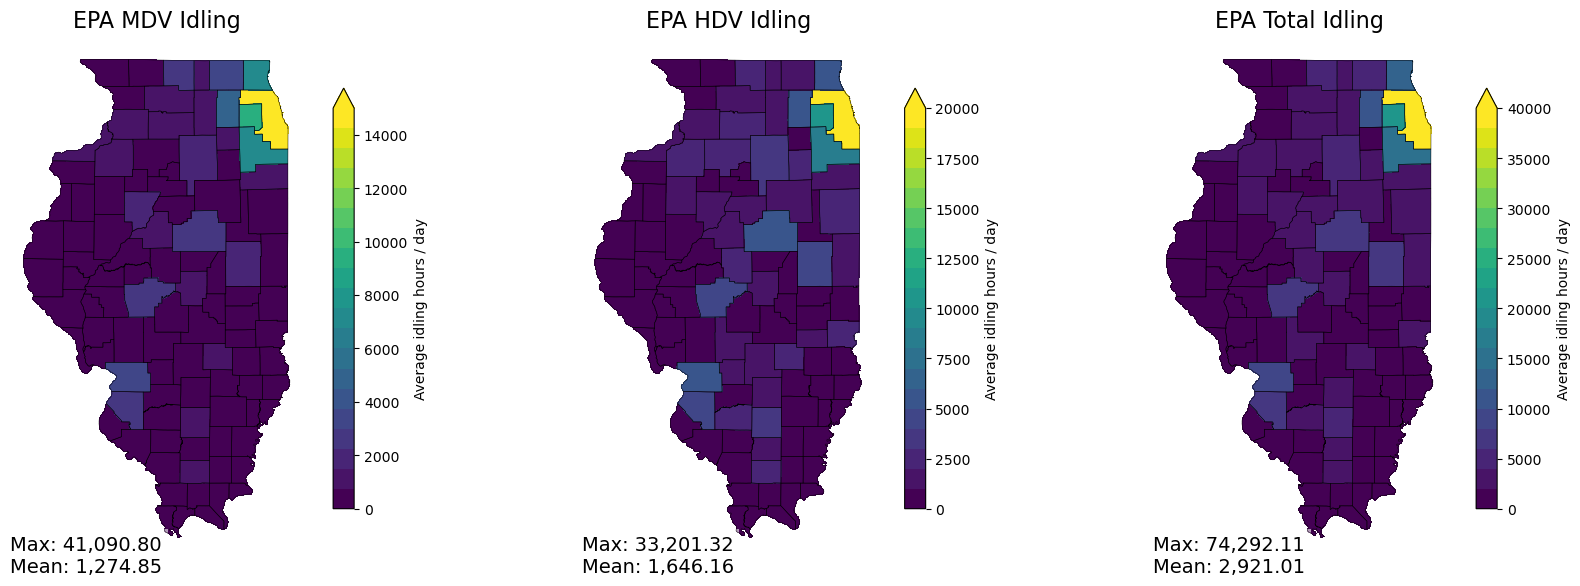

In [8]:
bwr_colors = plt.cm.viridis(np.linspace(0, 1, 20)) 
cmap_discrete = ListedColormap(bwr_colors)

panels = [("EPA_MDV_ONI", "EPA MDV Idling"), ("EPA_HDV_Total", "EPA HDV Idling"), ("EPA_Total", "EPA Total Idling")]
extents = {
    "EPA_MDV_ONI": (0, 15000),    
    "EPA_HDV_Total": (0, 20000),   
    "EPA_Total": (0, 40000),   
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, title) in zip(axes, panels):
    vmin, vmax = extents[col]
    
    county_out.plot(
        column=col,
        ax=ax,
        cmap=cmap_discrete,
        vmin=vmin,
        vmax=vmax,
        legend=True,
        legend_kwds={"shrink": 0.8, "label": "Average idling hours / day","extend":'max'},
        antialiased=False,
    )
    ax.set_axis_off()
    ax.set_title(title, fontsize=16)
    county_out.boundary.plot(ax=ax, color="k", linewidth=0.4, zorder=10, alpha=0.8)
    vals = county_out[col].replace([np.inf, -np.inf], np.nan).dropna()
    mx = float(vals.max()) if not vals.empty else float("nan")
    mu = float(vals.mean()) if not vals.empty else float("nan")

    ax.text(
        0.0, 0.05,
        f"Max: {mx:,.2f}\nMean: {mu:,.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=14,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

plt.tight_layout()
plt.show()

<h2> Calculate difference between EPA and LOCUS data (LOCUS - EPA)

In [13]:
il_mask = county_out["region_cd"].astype(str).str.zfill(5).str.startswith("17")

print("Illinois Annual Idling Hours\n")

print(f"EPA MDV ONI: {(county_out.loc[il_mask, 'EPA_MDV_ONI'].sum()*365):,.0f} hours/year")
print(f"EPA HDV ONI: {(county_out.loc[il_mask, 'EPA_HDV_ONI'].sum()*365):,.0f} hours/year")
print(f"EPA HDV Hotelling: {(county_out.loc[il_mask, 'EPA_HDV_HOTELING'].sum()*365):,.0f} hours/year")

print("\nLOCUS Annual Idling Hours\n")

print(f"LOCUS MDV: {(county_out.loc[il_mask, 'MDT_avg_da'].sum()*365):,.0f} hours/year")
print(f"LOCUS HDV: {(county_out.loc[il_mask, 'HDT_avg_da'].sum()*365):,.0f} hours/year")
print(f"LOCUS Total: {(county_out.loc[il_mask, 'Total_avg_'].sum()*365):,.0f} hours/year")

Illinois Annual Idling Hours

EPA MDV ONI: 47,462,606 hours/year
EPA HDV ONI: 32,793,225 hours/year
EPA HDV Hotelling: 28,493,270 hours/year

LOCUS Annual Idling Hours

LOCUS MDV: 76,652,841 hours/year
LOCUS HDV: 119,591,578 hours/year
LOCUS Total: 196,244,419 hours/year


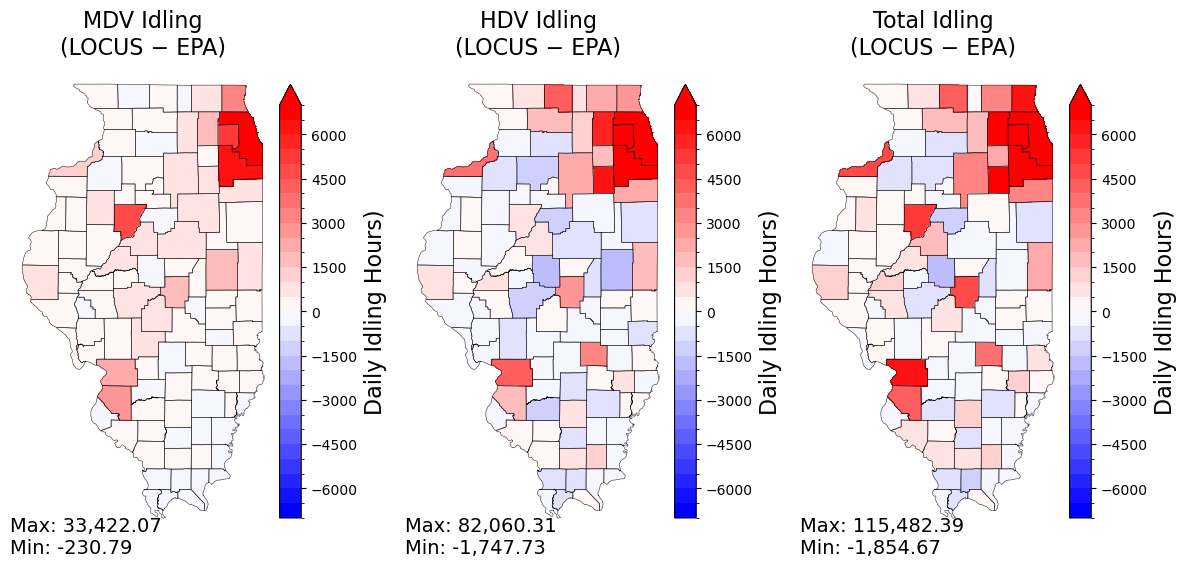

In [37]:
# calc diffs (LOCUS-EPA)
county_out["DIFF_MDV"] = county_out["MDT_avg_da"] - county_out["EPA_MDV_ONI"]
county_out["DIFF_HDV"] = county_out["HDT_avg_da"] - county_out["EPA_HDV_Total"]
county_out["DIFF_TOT"] = county_out["Total_avg_"] - county_out["EPA_Total"]

panels = [
    ("DIFF_MDV", "MDV Idling\n(LOCUS − EPA)"),
    ("DIFF_HDV", "HDV Idling\n(LOCUS − EPA)"),
    ("DIFF_TOT", "Total Idling\n(LOCUS − EPA)"),
]

# --------------------------------------------------
# Discrete diverging color setup
# --------------------------------------------------
DIFF_MIN = -7000
DIFF_MAX = 7000
N_DIFF_BINS = 28   # odd number so the middle color is white-ish

cmap_diff = ListedColormap(plt.cm.bwr(np.linspace(0, 1, N_DIFF_BINS)))
bounds = np.linspace(DIFF_MIN, DIFF_MAX, N_DIFF_BINS + 1)
norm_diff = BoundaryNorm(bounds, cmap_diff.N)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for ax, (col, title) in zip(axes, panels):

    county_out.plot(
        column=col,
        ax=ax,
        cmap=cmap_diff,
        norm=norm_diff,
        edgecolor="none",
        antialiased=False,
        vmin=DIFF_MIN,
        vmax=DIFF_MAX,
    )

    county_out.boundary.plot(ax=ax, color="k", linewidth=0.4, zorder=10, alpha=0.8)

    ax.set_axis_off()
    ax.set_title(title, fontsize=16)

    vals = county_out[col].replace([np.inf, -np.inf], np.nan).dropna()
    mn = float(vals.min()) if not vals.empty else float("nan")
    mx = float(vals.max()) if not vals.empty else float("nan")

    ax.text(
        0.0, 0.05,
        f"Max: {mx:,.2f}\nMin: {mn:,.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=14,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

# --------------------------------------------------
# Add one colorbar per subplot
# --------------------------------------------------
for ax in axes:
    cb = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm_diff, cmap=cmap_diff),
        ax=ax,
        shrink=0.8,
        pad=0.01,
        extend="max"
    )
    cb.set_label("Daily Idling Hours)", fontsize=16)

plt.tight_layout()
plt.show()

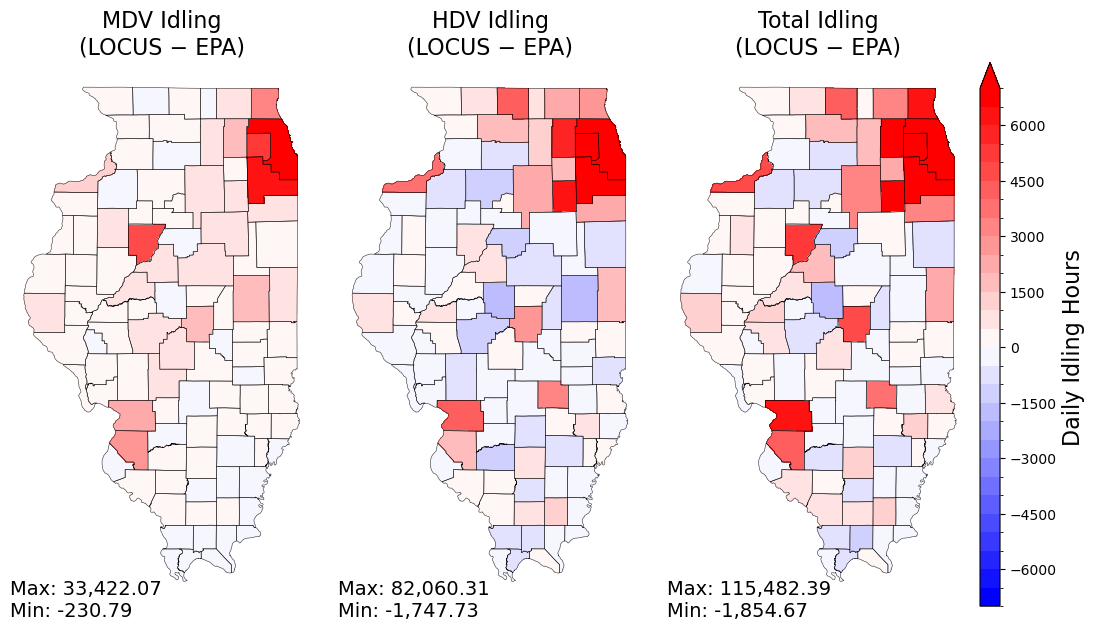

In [42]:
# calc diffs (LOCUS-EPA)
county_out["DIFF_MDV"] = county_out["MDT_avg_da"] - county_out["EPA_MDV_ONI"]
county_out["DIFF_HDV"] = county_out["HDT_avg_da"] - county_out["EPA_HDV_Total"]
county_out["DIFF_TOT"] = county_out["Total_avg_"] - county_out["EPA_Total"]

panels = [
    ("DIFF_MDV", "MDV Idling\n(LOCUS − EPA)"),
    ("DIFF_HDV", "HDV Idling\n(LOCUS − EPA)"),
    ("DIFF_TOT", "Total Idling\n(LOCUS − EPA)"),
]

# --------------------------------------------------
# Discrete diverging color setup
# --------------------------------------------------
DIFF_MIN = -7000
DIFF_MAX = 7000
N_DIFF_BINS = 28

cmap_diff = ListedColormap(plt.cm.bwr(np.linspace(0, 1, N_DIFF_BINS)))
bounds = np.linspace(DIFF_MIN, DIFF_MAX, N_DIFF_BINS + 1)
norm_diff = BoundaryNorm(bounds, cmap_diff.N)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(10, 6))

for ax, (col, title) in zip(axes, panels):

    county_out.plot(
        column=col,
        ax=ax,
        cmap=cmap_diff,
        norm=norm_diff,
        edgecolor="none",
        antialiased=False,
        vmin=DIFF_MIN,
        vmax=DIFF_MAX,
    )

    county_out.boundary.plot(ax=ax, color="k", linewidth=0.4, zorder=10, alpha=0.8)

    ax.set_axis_off()
    ax.set_title(title, fontsize=16)

    vals = county_out[col].replace([np.inf, -np.inf], np.nan).dropna()
    mn = float(vals.min()) if not vals.empty else float("nan")
    mx = float(vals.max()) if not vals.empty else float("nan")

    ax.text(
        0.0, 0.05,
        f"Max: {mx:,.2f}\nMin: {mn:,.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=14,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

# tighten layout first
plt.tight_layout()

# --------------------------------------------------
# Create colorbar axis to the right of last panel
# --------------------------------------------------
pos = axes[-1].get_position()

cax = fig.add_axes([
    pos.x1 + 0.01,   # small offset to right
    pos.y0,
    0.02,            # colorbar width
    pos.height
])

sm = plt.cm.ScalarMappable(norm=norm_diff, cmap=cmap_diff)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cax,
    extend="max"
)

cbar.set_label("Daily Idling Hours", fontsize=16)

plt.show()